Cloning the SIENNA Repository

In [1]:
!git clone https://github.com/ITrakNeuro/SIENNA---CD2.git

Cloning into 'SIENNA---CD2'...
remote: Enumerating objects: 1166, done.
remote: Counting objects: 100% (163/163), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 1166 (delta 60), reused 124 (delta 42), pack-reused 1003 (from 1)
Receiving objects: 100% (1166/1166), 215.82 MiB | 23.35 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (1001/1001), done.


In [2]:
%cd SIENNA---CD2

/content/SIENNA---CD2


Installing Dependencies

In [3]:
!pip install -r requirements.txt > /dev/null 2>&1


Importing Necessary Libraries

In [4]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from intensity_redistribution import adaptive_MRI_enhancement
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, roc_auc_score
from keras.models import load_model
import misc


# Running SIENNA on Clinical Dataset 2

Here, we retrieve and label clinical MRI slices from Clinical Dataset 2. For each tumor type, we randomly sample a pre-specified number of slices and apply the PREMO enhancement technique (part of the *adaptive_MRI_enhancement* module). Model predictions and analysis are carried out thereafter.

Please feel free to play around with the variable *slice_count* to control number of samples used in your analysis of SIENNA.

In [5]:
def process_patient(models):
    x = []
    y = []
    label = 0
    directory = '/content/SIENNA---CD2/Clinical Dataset 2'
    class_count = {0: 0, 1: 0, 2: 0}

    slice_count = 300  # Number of slices per class to be analyzed

    # Subdirectories
    class_dirs = {
        0: "pituitary",
        1: "meningioma",
        2: "glioma"
    }

    for label, class_name in class_dirs.items():
        class_path = os.path.join(directory, class_name)
        all_files = os.listdir(class_path)
        random_files = random.sample(all_files, min(slice_count, len(all_files))) #random slice_count samples retrieved from class folder
        for p in random_files:
            image_path = os.path.join(class_path, p)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image {image_path}")
                continue
            img = cv2.resize(img, (240, 240))

            he = adaptive_MRI_enhancement(img)
            img2 = he.PREMO()  # PREMO

            img = img2 / 255.0
            x.append(img)
            y.append(label)
            class_count[label] += 1

    y_train = to_categorical(y, 3)
    xa = np.array(x)
    ya = np.array(y_train)
    x_train = np.asarray(xa)
    y_train = np.asarray(ya)
    patient_results = {}

    # time to make prediction!
    for model_name, model in models.items():
        a = model.predict(x_train)
        y_pred = np.argmax(a, axis=1)
        y_true = np.argmax(y_train, axis=1)
        cm = confusion_matrix(y_true, y_pred)

        for i in range(cm.shape[0]):
            tp = cm[i, i]  # True positives
            fp = np.sum(cm[:, i]) - tp  # False positives
            fn = np.sum(cm[i, :]) - tp  # False negatives
            tn = np.sum(cm) - tp - fp - fn  # True negatives
            accuracy = (tp + tn) / np.sum(cm)
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

            try:
                auroc = roc_auc_score((y_true == i).astype(int), a[:, i])
            except ValueError:
                auroc = "AUROC cannot be calculated for this class (only one class present)"
            class_name = class_dirs.get(i, f"Unknown class {i}")

            if model_name not in patient_results:
                patient_results[model_name] = {}

            patient_results[model_name][class_name] = {
                "Accuracy": accuracy,
                "Precision": precision,
                "Recall": recall,
                "F1 Score": f1score,
                "AUROC": auroc,
                "FP": fp,
                "FN": fn,
                "TP": tp,
                "TN": tn,
            }

    return patient_results

Time to make predictions!
The pre-trained SIENNA weights have been loaded, and the model will now be run for the specified number of *experimental_runs*.

Feel free to adjust the *experimental_runs* variable to modify the number of times the model is executed and observe the results for different runs.



In [6]:
experimental_runs = 2 # n-random sumbsampling stratergy


models = {
    "SIENNA on Clinical Dataset 2": load_model('/content/SIENNA---CD2/SIENNA Pre-trained.h5'),

}
all_results = {}
for patient_id in range(1, experimental_runs+1):
    patient_name = f"Run {patient_id}"
    all_results[patient_name] = process_patient(models)
misc.print_neat_results(all_results)

25/25 [==============================] - 4s 129ms/step

========== Results for Run 1 ==========

Model: SIENNA on Clinical Dataset 2

Class: pituitary
  Accuracy: 0.97
  Precision: 0.94
  Recall: 0.99
  F1 Score: 0.96

Class: meningioma
  Accuracy: 0.92
  Precision: 0.82
  Recall: 0.90
  F1 Score: 0.86

Class: glioma
  Accuracy: 0.93
  Precision: 0.97
  Recall: 0.85
  F1 Score: 0.91


========== Results for Run 2 ==========

Model: SIENNA on Clinical Dataset 2

Class: pituitary
  Accuracy: 0.97
  Precision: 0.94
  Recall: 0.99
  F1 Score: 0.96

Class: meningioma
  Accuracy: 0.94
  Precision: 0.87
  Recall: 0.90
  F1 Score: 0.88

Class: glioma
  Accuracy: 0.95
  Precision: 0.97
  Recall: 0.89
  F1 Score: 0.93



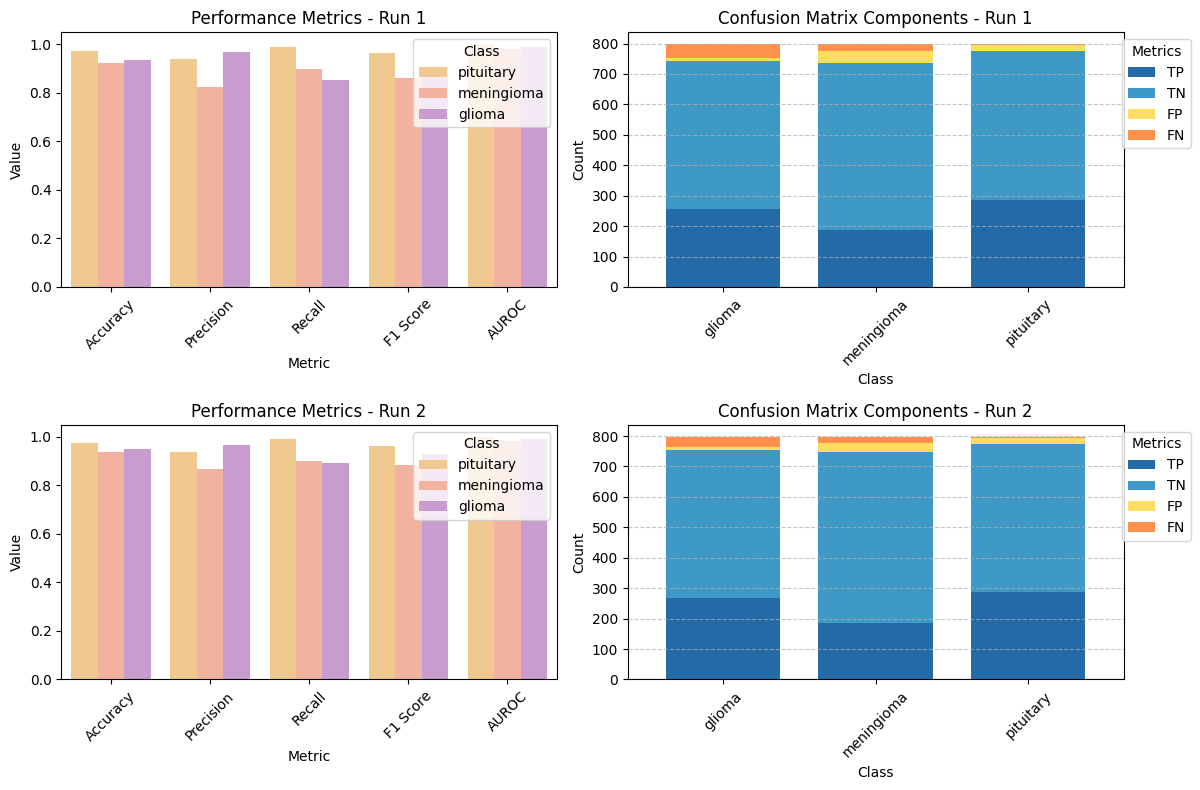

In [7]:
misc.plot(all_results)

# SIENNA's Architecture and Parameter Count

In [8]:
models["SIENNA on Clinical Dataset 2"].summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 cv1 (Conv2D)                (None, 60, 60, 74)        962       
                                                                 
 activation_20 (Activation)  (None, 60, 60, 74)        0         
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 30, 30, 74)        0         
 ng2D)                                                           
                                                                 
 dropout_20 (Dropout)        (None, 30, 30, 74)        0         
                                                                 
 cv2 (Conv2D)                (None, 8, 8, 64)          118464    
                                                                 
 activation_21 (Activation)  (None, 8, 8, 64)          0         
                                                      

# MAPPING PERFORMANCE ON EXCEL

We log the results of the experimental runs into an Excel sheet for further analysis. Each row in the sheet corresponds to a different experimental run, with performance metrics for each tumor type logged under their respective columns. In this analysis, we mimic the n-fold repeated random sub-sampling testing strategy to evaluate and quantify the stability and robustness of the SIENNA model.

To proceed with the analysis, users are required to create a personal copy of the provided Google Sheets template by following these steps:

1. Click on the link: [Google Sheets Template](https://docs.google.com/spreadsheets/d/1bdG_b5g0wm0MjdU_zUypXLfCYQWqQGaxvUix_Hc-qd8/edit?usp=sharing).
2. Once the template opens, go to the "File" menu and select "Make a copy".
3. Save the copy to your personal Google Drive.

After saving the sheet to your personal drive, follow these steps:

4. Retrieve the worksheet key from the URL of your copied Google Sheet. This is the long string of characters located between /d/ and /edit in the URL.
For example, in the template URL

docs.google.com/spreadsheets/d/***1bdG_b5g0wm0MjdU_zUypXLfCYQWqQGaxvUix_Hc-qd8***/edit

 the key is 1bdG_b5g0wm0MjdU_zUypXLfCYQWqQGaxvUix_Hc-qd8.
Store this worksheet key in the variable SHEET_KEY:

In [ ]:
SHEET_KEY='TEMP_KEY'

In [109]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

import pandas as pd

gc = gspread.authorize(creds)
wb = gc.open_by_key(SHEET_KEY)
ws = wb.worksheet('Sheet2')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [110]:
ws.delete_rows(10,107)
import openpyxl

row_count = 1

tumor_types = ['pituitary', 'meningioma', 'glioma']
for run_name, run_data in all_results.items():
    for experiment, tumors in run_data.items():
        row_data = [row_count]

        for tumor_type in tumor_types:
            metrics = tumors[tumor_type]
            accuracy = metrics['Accuracy']
            precision = metrics['Precision']
            recall = metrics['Recall']
            f1_score = metrics['F1 Score']
            auroc = metrics['AUROC']
            tp = metrics['TP']
            tn = metrics['TN']
            fp = metrics['FP']
            fn = metrics['FN']
            row_data.extend([
                float(accuracy), float(precision), float(recall), float(f1_score), float(auroc), int(tp), int(tn), int(fp), int(fn)
            ])

        ws.append_row(row_data,table_range='A11:G107')

        row_count += 1

        tf.keras.backend.clear_session()